## Dataset from Watson Studio
Accessing the credit card fraud dataset using project token

In [2]:
import pandas as pd
import numpy as np
from ibm_watson_studio_lib import access_project_or_space
# Initialize Watson Studio library with your project token
# Replace <PROJECT_TOKEN> with the long token you copied earlier
wslib = access_project_or_space({"token": "p-2+lIJRm3tk/JH1/jcu+kAfmQ==;lSLR/3v5WFu0/EIT6I68Jw==:mf7rlWIwMJRA2F5sQ2LOR41B7/RYYocgUgDTmA5U5tkBhNM2yTHtJIIlkiB3i+189/sz4iZzxLqVn0YP9QNXvHXZ87+sOhJxcw=="})
# Download the dataset file to the notebook environment
wslib.download_file("creditcard.csv")
print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [3]:
# Load CSV into pandas DataFrame
df = pd.read_csv("creditcard.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset loaded: 284,807 rows, 31 columns

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Part 2: Exploratory Data Analysis
Understanding fraud patterns and class imbalance

In [5]:
# Dataset shape and structure
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
# Check for missing values
missing_count = df.isnull().sum().sum()
print(f"\nTotal missing values: {missing_count}")
if missing_count == 0:
    print("✓ Clean dataset - no missing values!")

Dataset shape: (284807, 31)

Column names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
float64    30
int64       1
Name: count, dtype: int64

Total missing values: 0
✓ Clean dataset - no missing values!


In [8]:
# Class distribution - THE KEY CHALLENGE
print("Class Distribution:")
print(df['Class'].value_counts())
print("\nPercentages:")
print(df['Class'].value_counts(normalize=True) * 100)
# Calculate fraud percentage
fraud_count = df['Class'].sum()
total_count = len(df)
fraud_ratio = (fraud_count / total_count) * 100
print(f"\n￿ Fraud Rate: {fraud_ratio:.3f}%")
print(f"This means only {fraud_count} out of {total_count:,}transactions are fraud!")
print(f"Imbalance ratio: {total_count / fraud_count:.1f}:1")

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

￿ Fraud Rate: 0.173%
This means only 492 out of 284,807transactions are fraud!
Imbalance ratio: 578.9:1


In [9]:
# Statistical summary
print("Feature Statistics:")
df.describe()

Feature Statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Part 3: Data Preprocessing
Feature scaling and train-test split with stratification

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Separate features (X) from target (y)
X = df.drop(columns='Class')
y = df['Class']
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (284807, 30)
Target shape: (284807,)


In [12]:
# StandardScaler: mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features normalized!")
print(f"Scaled features shape: {X_scaled.shape}")

Features normalized!
Scaled features shape: (284807, 30)


In [13]:
# Split with STRATIFICATION (critical for imbalanced data!)
X_train, X_test, y_train, y_test = train_test_split(
X_scaled,
y,
test_size=0.2,
random_state=42,
stratify=y # Maintains fraud ratio in both sets
)
print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
# Verify fraud rate preserved
train_fraud_rate = y_train.mean() * 100
test_fraud_rate = y_test.mean() * 100
print(f"\nTrain fraud rate: {train_fraud_rate:.3f}%")
print(f"Test fraud rate: {test_fraud_rate:.3f}%")

Training set: 227,845 samples
Test set: 56,962 samples

Train fraud rate: 0.173%
Test fraud rate: 0.172%


## Part 4: Model Training
Building a baseline fraud detection classifier

In [14]:
from sklearn.linear_model import LogisticRegression
import time
# Initialize Logistic Regression
clf = LogisticRegression(
max_iter=1000, # Ensure convergence
random_state=42
)
# Train and time
print("Training Logistic Regression model...")
start_time = time.time()
clf.fit(X_train, y_train)
training_time = time.time() - start_time
print(f"✓ Model trained in {training_time:.2f} seconds")

Training Logistic Regression model...
✓ Model trained in 0.60 seconds


## Part 5: Model Evaluation
Analyzing performance with imbalanced-aware metrics

In [17]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
# Make predictions
y_pred = clf.predict(X_test)
# Overall accuracy (will be misleading!)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("￿￿ High accuracy doesn't mean good fraud detection!\n")
# Detailed metrics per class
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate(0)', 'Fraud (1)']))

Accuracy: 0.9992 (99.92%)
￿￿ High accuracy doesn't mean good fraud detection!

Classification Report:
               precision    recall  f1-score   support

Legitimate(0)       1.00      1.00      1.00     56864
    Fraud (1)       0.83      0.64      0.72        98

     accuracy                           1.00     56962
    macro avg       0.91      0.82      0.86     56962
 weighted avg       1.00      1.00      1.00     56962




Confusion Matrix Values:
True Negatives (TN): 56,851
False Positives (FP): 13 ← Legitimate flagged as fraud
False Negatives (FN): 35 ← Fraud missed! ￿
True Positives (TP): 63 ← Fraud caught!


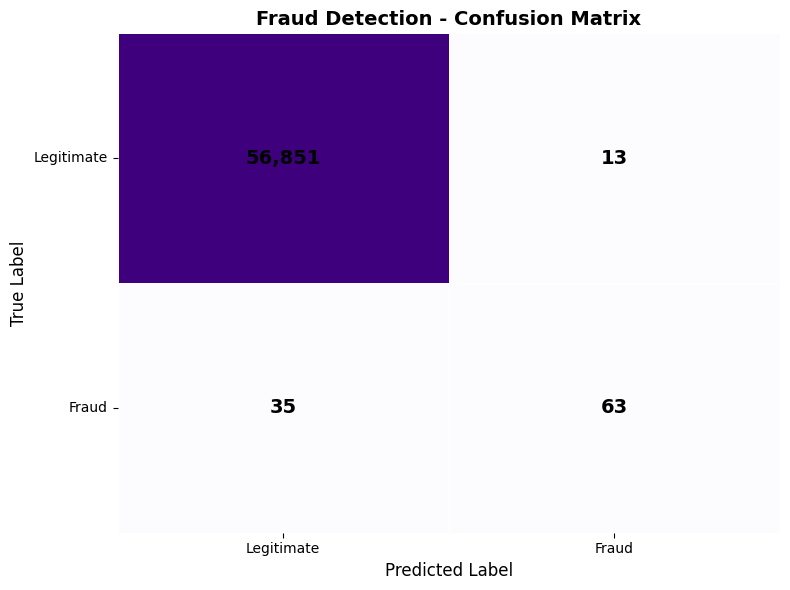

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("\nConfusion Matrix Values:")
print(f"True Negatives (TN): {cm[0,0]:,}")
print(f"False Positives (FP): {cm[0,1]:,} ← Legitimate flagged as fraud")
print(f"False Negatives (FN): {cm[1,0]:,} ← Fraud missed! ￿")
print(f"True Positives (TP): {cm[1,1]:,} ← Fraud caught!")
# Visualize (with Watson Studio workaround for label bug)
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, cmap='Purples', cbar=False, linewidths=0.5)
# Force tick labels (Watson bug workaround)
ax.set_xticklabels(['Legitimate', 'Fraud'])
ax.set_yticklabels(['Legitimate', 'Fraud'], rotation=0)
# Manually annotate cells (guaranteed visible)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, f"{cm[i, j]:,}",ha="center", va="center",color="black", fontsize=14, fontweight='bold',zorder=3, transform=ax.transData)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Fraud Detection - Confusion Matrix', fontsize=14,
fontweight='bold')
plt.tight_layout()
plt.show()

## Part 6: Model Comparison
Experimenting with Random Forest and class weighting

In [24]:
from sklearn.ensemble import RandomForestClassifier
# Train Random Forest with balanced class weights
# class_weight='balanced' automatically adjusts for imbalance
rf = RandomForestClassifier(
class_weight='balanced', # Penalize misclassifying minority class
n_estimators=100,
max_depth=20,
random_state=42,
n_jobs=-1, # Use all CPU cores
verbose=1
)
print("Training Random Forest (this may take 1-2 minutes)...")
start_time = time.time()
rf.fit(X_train, y_train)
rf_training_time = time.time() - start_time
print(f"✓ Random Forest trained in {rf_training_time:.2f} seconds")

Training Random Forest (this may take 1-2 minutes)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   29.2s


✓ Random Forest trained in 67.85 seconds


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.1min finished


In [26]:

# Predict and evaluate
y_pred_rf = rf.predict(X_test)
print("\nRandom Forest Performance:")
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate(0)', 'Fraud (1)']))
# Compare to Logistic Regression
from sklearn.metrics import f1_score
lr_f1 = f1_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred_rf)
print(f"\nModel Comparison (Fraud Class F1-Score):")
print(f"Logistic Regression: {lr_f1:.4f}")
print(f"Random Forest: {rf_f1:.4f}")
print(f"\nImprovement: {((rf_f1 - lr_f1) / lr_f1 * 100):.1f}%")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.2s finished



Random Forest Performance:
               precision    recall  f1-score   support

Legitimate(0)       1.00      1.00      1.00     56864
    Fraud (1)       0.94      0.76      0.84        98

     accuracy                           1.00     56962
    macro avg       0.97      0.88      0.92     56962
 weighted avg       1.00      1.00      1.00     56962


Model Comparison (Fraud Class F1-Score):
Logistic Regression: 0.7241
Random Forest: 0.8362

Improvement: 15.5%
